# 循环神经网络

## 序列模型

### 训练

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

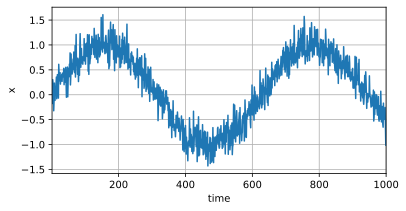

In [2]:
T = 1000 # 总共产生1000个点
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1, 1000], figsize=(6, 3))

In [3]:
tau = 4
features = torch.zeros((T - tau, tau))

for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

In [4]:
batch_size, n_train = 16, 600
# 只有前n_trian个样本用于训练
train_iter = d2l.load_array((features[:n_train], labels[:n_train]),
                            batch_size, is_train=True)

In [5]:
# 初始化网络权重的函数
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weight)
    return net

# 平方损失。注意：MSELoss计算平方误差时不带系数1/2
loss = nn.MSELoss(reduction='none')

In [6]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1},'
            f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1,loss: 0.076652
epoch 2,loss: 0.061964
epoch 3,loss: 0.058477
epoch 4,loss: 0.057632
epoch 5,loss: 0.057012


e:\Anaconda_envs\envs\d2l\lib\site-packages\d2l\torch.py:3520: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:823.)
  self.data = [a + float(b) for a, b in zip(self.data, args)]


### 预测

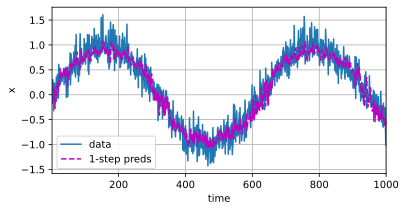

In [7]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
        [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
        'x', legend=['data', '1-step preds'], xlim=[1, 1000],
        figsize=(6, 3)
        )

通常，对于直到$x_t$的观测序列，其在时间步$\hat{x}_{t + k}$处的预测输出称为$k$步预测（k-step-ahead-prediction）。由于我们的观察已经到了$x_{604}$，它的$k$步预测是$\hat{x}_{604+k}$。换句话说，我们必须使⽤我们⾃⼰的预测（⽽不是原始数据）来进⾏多步预测。让我们看看效果如何。

In [8]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1))
    )

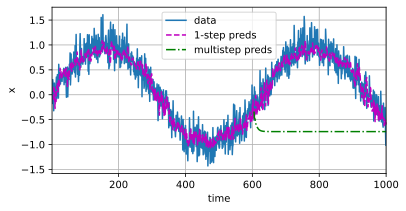

In [9]:
d2l.plot([time, time[tau:], time[n_train + tau:]],
        [x.detach().numpy(), onestep_preds.detach().numpy(),
        multistep_preds[n_train + tau:].detach().numpy()], 'time',
        'x', legend=['data', '1-step preds', 'multistep preds'],
        xlim=[1, 1000], figsize=(6, 3)
        )

如上⾯的例⼦所⽰，绿线的预测显然并不理想。经过⼏个预测步骤之后，预测的结果很快就会衰减到⼀个常数。为什么这个算法效果这么差呢？事实是由于错误的累积：假设在步骤1之后，我们积累⼀些错误$\epsilon_1 = \overline{\epsilon}$，于是，步骤2的输⼊被扰动了$\epsilon_1$，结果积累的误差是依照次序的$\epsilon_2 = \overline{\epsilon} + c\epsilon_1$，其中$c$为某个常数，后⾯的预测误差依此类推。因此误差可能会相当快地偏离真实的观测结果。例如，未来$24$⼩时的天⽓预报往往相当准确，但超过这⼀点，精度就会迅速下降。我们将在本章及后续章节中讨论如何改进这⼀点。

In [10]:
# 基于k = 1, 4, 16, 64，通过对整个序列预测的计算，让我们更仔细地看一下k步预测的困难
max_steps = 64
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i(i < tau)是来自x的观测，其时间步从(i)到(i + T - tau - max_steps + 1)
for i in range(tau):
    features[:, i] = x[i:i + T - tau - max_steps + 1]

# 列i(i >= tau)是来自(i - tau + 1)步的预测，其时间步从(i)大(i + T - tau - max_steps + 1)
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

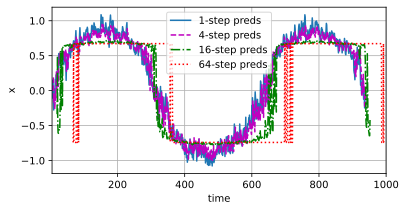

In [11]:
steps = (1, 4, 16, 64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
        [features[:, tau + i - 1].detach().numpy() for i in steps], 'time', 'x',
        legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
        figsize=(6, 3))

### 小结

- 内插法（在现有观测值之间进⾏估计）和外推法（对超出已知观测范围进⾏预测）在实践的难度上差别很⼤。因此，对于所拥有的序列数据，在训练时始终要尊重其时间顺序，即最好不要基于来的数据进⾏训练。
- 对于直到时间步的观测序列，其在时间步的预测输出是“步预测”。随着我们对预测时值的增加，会造成误差的快速累积和预测质量的极速下降。

## 文本预处理

本节中，我们将解析⽂本的常⻅预处理步骤。这些步骤通常包括：
1. 将⽂本作为字符串加载到内存中。
2. 将字符串拆分为词元（如单词和字符）。
3. 建⽴⼀个词表，将拆分的词元映射到数字索引。
4. 将⽂本转换为数字索引序列，⽅便模型操作。

In [12]:
import collections
import re
from d2l import torch as d2l

### 读取数据集

In [13]:
#@save
d2l.DATA_HUB['time_machine'] = (d2l.DATA_URL + 'timemachine.txt', '090b5e7e70c295757f55df93cb0a180b9691891a')

def read_time_machine(): #@save
    """将时间机器数据集加载到文本行的列表中"""
    with open(d2l.download('time_machine'), 'r') as f:
        lines = f.readlines()
    return [re.sub('[^A-Za-z]+', ' ', line).strip().lower() for line in lines]

lines = read_time_machine()
print(f'# 文本总行数: {len(lines)}')
print(lines[0])
print(lines[10])

# 文本总行数: 3221
the time machine by h g wells
twinkled and his usually pale face was flushed and animated the


### 词元化

In [14]:
def tokenize(lines, token='word'): #@save
    """将文本行拆分为单词或字符词元"""
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('错误：未知词元类型：' + token)

tokens = tokenize(lines)
for i in range(11):
    print(tokens[i])

['the', 'time', 'machine', 'by', 'h', 'g', 'wells']
[]
[]
[]
[]
['i']
[]
[]
['the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him']
['was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and']
['twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the']


### 词表

词元的类型是字符串，⽽模型需要的输⼊是数字，因此这种类型不⽅便模型使⽤。现在，让我们构建⼀个字典，通常也叫做词表（vocabulary），⽤来将字符串类型的词元映射到从开始的数字索引中。我们先将训练集中的所有⽂档合并在⼀起，对它们的唯⼀词元进⾏统计，得到的统计结果称之为语料（corpus）。然后根据每个唯⼀词元的出现频率，为其分配⼀个数字索引。很少出现的词元通常被移除，这可以降低复杂性。另外，语料库中不存在或已删除的任何词元都将映射到⼀个特定的未知词元“<unk>”。我们可以选择增加⼀个列表，⽤于保存那些被保留的词元，例如：填充词元（“<pad>”）；序列开始词元（“<bos>”）；序列结束词元（“<eos>”）

In [15]:
class Vocab: #@save
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []
        # 按出现频率排序
        counter = count_corpus(tokens)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        # 未知词元的索引为0
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {
            token:idx for idx, token in enumerate(self.idx_to_token)
        }
        for token, freq in self._token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.to_token(index) for index in indices]
    
    @property # 加了property后，可以像访问属性一样直接访问，不用加括号
    def unk(self): # 未知词元的索引为0
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def count_corpus(tokens): #@save
    """统计词元的频率"""
    # 这里的tokens是1D列表或2D列表
    if len(tokens) == 0 or isinstance(tokens[0], list):
        # 将词元列表展平成一个列表
        tokens = [token for line in tokens for token in line]
    return collections.Counter(tokens)

In [16]:
vocab = Vocab(tokens)
print(list(vocab.token_to_idx.items())[:10])

[('<unk>', 0), ('the', 1), ('i', 2), ('and', 3), ('of', 4), ('a', 5), ('to', 6), ('was', 7), ('in', 8), ('that', 9)]


In [17]:
for i in [0, 10]:
    print('文本:', tokens[i])
    print('索引:', vocab[tokens[i]])

文本: ['the', 'time', 'machine', 'by', 'h', 'g', 'wells']
索引: [1, 19, 50, 40, 2183, 2184, 400]
文本: ['twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the']
索引: [2186, 3, 25, 1044, 362, 113, 7, 1421, 3, 1045, 1]


### 整合所有功能

1. 为了简化后⾯章节中的训练，我们使⽤字符（⽽不是单词）实现⽂本词元化；
2. 时光机器数据集中的每个⽂本⾏不⼀定是⼀个句⼦或⼀个段落，还可能是⼀个单词，因此返回的corpus仅处理为单个列表，⽽不是使⽤多词元列表构成的⼀个列表。

In [18]:
def load_corpus_time_machine(max_tokens=-1): #@save
    """返回时光机器数据集的词元索引列表和词表"""
    lines = read_time_machine()
    tokens = tokenize(lines, 'char')
    vocab = Vocab(tokens)
    # 因为时光机器数据集中的每个文本行不一定是一个句子或一个段落
    # 所以将所有文本行展平到一个列表中
    corpus = [vocab[token] for line in tokens for token in line]
    if max_tokens > 0:
        corpus = corpus[:max_tokens]
    return corpus, vocab

corpus, vocab = load_corpus_time_machine()
len(corpus), len(vocab)

(170580, 28)

## 语言模型和数据集

### 马尔可夫模型与n元语法

在讨论包含深度学习的解决方案之前，我们需要了解更多的概念和术语。回想一下我们在 8.1 节中对马尔可夫模型的讨论，并且将其应用于语言建模。如果 $P(x_{t+1} \mid x_t, \dots, x_1) = P(x_{t+1} \mid x_t)$，则序列上的分布满足一阶马尔可夫性质。阶数越高，对应的依赖关系就越长。这种性质推导出了许多可以应用于序列建模的近似公式：

$$
\begin{aligned}
P(x_1, x_2, x_3, x_4) &= P(x_1)P(x_2)P(x_3)P(x_4), \\
P(x_1, x_2, x_3, x_4) &= P(x_1)P(x_2 \mid x_1)P(x_3 \mid x_2)P(x_4 \mid x_3), \\
P(x_1, x_2, x_3, x_4) &= P(x_1)P(x_2 \mid x_1)P(x_3 \mid x_1, x_2)P(x_4 \mid x_2, x_3).
\end{aligned}
$$

通常，涉及一个、两个和三个变量的概率公式分别被称为一元语法（unigram）、二元语法（bigram）和三元语法（trigram）模型。下面，我们将学习如何去设计更好的模型。

### 自然语言统计

In [19]:
import random
import torch
from d2l import torch as d2l

In [20]:
tokens = d2l.tokenize(d2l.read_time_machine())
# 因为每个文本行不一定是一个句子或一个段落，因此我们把所有文本行凭借到一起
corpus = [token for line in tokens for token in line]
vocab = d2l.Vocab(corpus)
vocab.token_freqs[:10]

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

有个明显的问题是词频衰减的速度相当地快。例如，最常⽤单词的词频对⽐，第10个还不到第1个的1/5。为了更好地理解，我们可以画出的词频图：

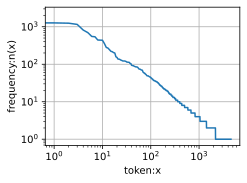

In [21]:
freqs = [freq for token, freq in vocab.token_freqs]
d2l.plot(freqs, xlabel='token:x', ylabel='frequency:n(x)',
        xscale='log', yscale='log')

通过此图我们可以发现：词频以⼀种明确的⽅式迅速衰减。将前⼏个单词作为例外消除后，剩余的所有单词⼤致遵循双对数坐标图上的⼀条直线。这意味着单词的频率满⾜⻬普夫定（Zipf’slaw），即第$i$个最常⽤单词的频率$n_i$为：
$$n_i \propto \frac{1}{i^\alpha}$$
等价于
$$\log n_i = -\alpha \log i + c$$
其中$\alpha$是刻画分布的指数，$c$是常数。。这告诉我们想要通过计数统计和平滑来建模单词是不可⾏的，因为这样建模的结果会⼤⼤⾼估尾部单词的频率，也就是所谓的不常⽤单词。那么其他的词元组合，⽐如⼆元语法、三元语法等等，⼜会如何呢？我们来看看⼆元语法的频率是否与元语法的频率表现出相同的⾏为⽅式。

In [22]:
bigram_tokens = [pair for pair in zip(corpus[:-1], corpus[1:])]
bigram_vocab = d2l.Vocab(bigram_tokens)
bigram_vocab.token_freqs[:10]

[(('of', 'the'), 309),
 (('in', 'the'), 169),
 (('i', 'had'), 130),
 (('i', 'was'), 112),
 (('and', 'the'), 109),
 (('the', 'time'), 102),
 (('it', 'was'), 99),
 (('to', 'the'), 85),
 (('as', 'i'), 78),
 (('of', 'a'), 73)]

In [23]:
trigram_tokens = [triple for triple in zip(corpus[:-2], corpus[1:-1], corpus[2:])]
trigram_vocab = d2l.Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[(('the', 'time', 'traveller'), 59),
 (('the', 'time', 'machine'), 30),
 (('the', 'medical', 'man'), 24),
 (('it', 'seemed', 'to'), 16),
 (('it', 'was', 'a'), 15),
 (('here', 'and', 'there'), 15),
 (('seemed', 'to', 'me'), 14),
 (('i', 'did', 'not'), 14),
 (('i', 'saw', 'the'), 13),
 (('i', 'began', 'to'), 13)]

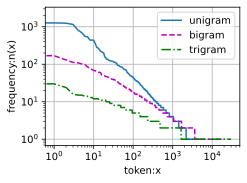

In [24]:
bigram_freqs = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]
d2l.plot([freqs, bigram_freqs, trigram_freqs], xlabel='token:x',
        ylabel='frequency:n(x)', xscale='log', yscale='log',
        legend = ['unigram', 'bigram', 'trigram'])

这张图⾮常令⼈振奋！原因有很多：
1. 除了⼀元语法词，单词序列似乎也遵循⻬普夫定律，尽管式(8.3.7)中的指数$\alpha$更⼩（指数的⼤⼩受序列⻓度的影响）；
2. 词表中$n$元组的数量并没有那么⼤，这说明语⾔中存在相当多的结构，这些结构给了我们应⽤模型的希望；
3. 很多元组很少出现，这使得拉普拉斯平滑⾮常不适合语⾔建模。作为代替，我们将使⽤基于深度学习的模型。

### 读取长序列数据

在介绍该模型之前，我们看⼀下总体策略。假设我们将使⽤神经⽹络来训练语⾔模型，模型中的⽹络⼀次处理具有预定义⻓度（例如$n$个时间步）的⼀个⼩批量序列。现在的问题是如何随机⽣成⼀个⼩批量数据的特征和标签以供读取。

<div align="center">
    <img src="../img/分割文本.png">
<div>
相当于一个长度为$n$的滑动窗口

我们应该从图中选择哪⼀个呢？事实上，他们都⼀样的好。然⽽，如果我们只选择⼀个偏移量，那么⽤于训练⽹络的、所有可能的⼦序列的覆盖范围将是有限的。因此，我们可以从随机偏移量开始划分序列，以同时获得覆盖性（coverage）和随机性（randomness）。下⾯，我们将描述如何实现随机采样（randomsampling）和顺序分区（sequentialpartitioning）策略。

#### 随机采样

在随机采样中，每个样本都是在原始的⻓序列上任意捕获的⼦序列。在迭代过程中，来⾃两个相邻的、随机的、⼩批量中的⼦序列不⼀定在原始序列上相邻。对于语⾔建模，⽬标是基于到⽬前为⽌我们看到的词元来预测下⼀个词元，因此标签是移位了⼀个词元的原始序列。

In [25]:
# batch_size指定了每个⼩批量中⼦序列样本的数⽬，num_steps是每个⼦序列中预定义的时间步数。
def seq_data_iter_random(corpus, batch_size, num_steps): #@save
    """使用随机抽样生成一个小批量子序列"""
    # 从随机偏移量开始对序列进行分区，随机范围包括num_steps-1
    corpus = corpus[random.randint(0, num_steps - 1):]
    # 减去1，是因为我们需要考虑标签
    num_subseqs = (len(corpus) - 1) // num_steps
    # 长度为num_steps的子序列的其实索引
    initial_indices = list(range(0, num_subseqs * num_steps, num_steps))
    # 在随机抽样的迭代过程中，
    # 来自两个相邻的、随机的、小批量中的子序列不一定在原始序列上相邻
    random.shuffle(initial_indices)

    def data(pos):
        # 返回从pos位置开始的长度为num_steps的序列
        return corpus[pos:pos + num_steps]

    num_batches = num_subseqs // batch_size
    for i in range(0, batch_size * num_batches, batch_size):
        # 在这里，initial_indices包含子序列的随机起始索引
        initial_indices_per_batch = initial_indices[i:i + batch_size]
        X = [data(j) for j in initial_indices_per_batch]
        Y = [data(j + 1) for j in initial_indices_per_batch]
        yield torch.tensor(X), torch.tensor(Y)

In [26]:
my_seq = list(range(35))
for X, Y in seq_data_iter_random(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY: ', Y)

X:  tensor([[17, 18, 19, 20, 21],
        [22, 23, 24, 25, 26]]) 
Y:  tensor([[18, 19, 20, 21, 22],
        [23, 24, 25, 26, 27]])
X:  tensor([[ 7,  8,  9, 10, 11],
        [27, 28, 29, 30, 31]]) 
Y:  tensor([[ 8,  9, 10, 11, 12],
        [28, 29, 30, 31, 32]])
X:  tensor([[12, 13, 14, 15, 16],
        [ 2,  3,  4,  5,  6]]) 
Y:  tensor([[13, 14, 15, 16, 17],
        [ 3,  4,  5,  6,  7]])


#### 顺序分区

在迭代过程中，除了对原始序列可以随机抽样外，我们还可以保证两个相邻的⼩批量中的⼦序列在原始序列上也是相邻的。这种策略在基于⼩批量的迭代过程中保留了拆分的⼦序列的顺序，因此称为顺序分区。

In [27]:
def seq_data_iter_sequential(corpus, batch_size, num_steps): #@save
    """使用顺序分区生成一个小批量子序列"""
    # 从随机偏移量开始划分序列
    offset = random.randint(0, num_steps)
    num_tokens = ((len(corpus) - offset - 1) // batch_size) * batch_size
    Xs = torch.tensor(corpus[offset:offset + num_tokens])
    Ys = torch.tensor(corpus[offset + 1:offset + 1 + num_tokens])
    Xs, Ys = Xs.reshape(batch_size, -1), Ys.reshape(batch_size, -1)
    num_batches = Xs.shape[1] // num_steps
    for i in range(0, num_steps * num_batches, num_steps):
        X = Xs[:, i:i + num_steps]
        Y = Ys[:, i:i + num_steps]
        yield X, Y

In [28]:
for X, Y in seq_data_iter_sequential(my_seq, batch_size=2, num_steps=5):
    print('X: ', X, '\nY: ', Y)

X:  tensor([[ 0,  1,  2,  3,  4],
        [17, 18, 19, 20, 21]]) 
Y:  tensor([[ 1,  2,  3,  4,  5],
        [18, 19, 20, 21, 22]])
X:  tensor([[ 5,  6,  7,  8,  9],
        [22, 23, 24, 25, 26]]) 
Y:  tensor([[ 6,  7,  8,  9, 10],
        [23, 24, 25, 26, 27]])
X:  tensor([[10, 11, 12, 13, 14],
        [27, 28, 29, 30, 31]]) 
Y:  tensor([[11, 12, 13, 14, 15],
        [28, 29, 30, 31, 32]])


现在，我们将上⾯的两个采样函数包装到⼀个类中，以便稍后可以将其⽤作数据迭代器。

In [29]:
class SeqDataLoader: #@save
    """加载序列数据的迭代器"""
    def __init__(self, batch_size, num_steps, use_random_iter, max_tokens):
        if use_random_iter:
            self.data_iter_fn = d2l.seq_data_iter_random
        else:
            self.data_iter_fn = d2l.seq_data_iter_sequential
        self.corpus, self.vocab = d2l.load_corpus_time_machine(max_tokens)
        self.batch_size, self.num_steps = batch_size, num_steps

    def __iter__(self):
        return self.data_iter_fn(self.corpus, self.batch_size, self.num_steps)

最后，我们定义了⼀个函数load_data_time_machine，它同时返回数据迭代器和词表，因此可以与其他带有load_data前缀的函数（如3.5节中定义的d2l.load_data_fashion_mnist）类似地使⽤。

In [30]:
def load_data_time_machine(batch_size, num_steps,
                            use_random_iter=False, max_tokens=10000): #@save
    """返回时光机器数据集的迭代器和词表"""
    data_iter = SeqDataLoader(
        batch_size, num_steps, use_random_iter, max_tokens)
    return data_iter, data_iter.vocab

### 有隐状态的循环神经网络

隐状态由当前时间步的输⼊与前⼀个时间步的隐藏变量⼀起计算得出：
$$
\pmb{H}_t = \phi(\pmb{X}_t \pmb{W}_{xh} + \pmb{H}_{t - 1} \pmb{W}_{hh} + \pmb{b}_h)
$$

输出：
$$
\pmb{O}_t = \pmb{H}_t \pmb{W}_{hq} + \pmb{b}_q
$$

隐状态中$\pmb{X}_t \pmb{W}_{xh} + \pmb{H}_{t - 1} \pmb{W}_{hh}$的计算，相当于$\pmb{X}_t$和$\pmb{H}_{t - 1}$的拼接与$\pmb{W}_{xh}$和$\pmb{W}_{hh}$的拼接的矩阵乘法。

虽然这个性质可以通过数学证明，但在下⾯我们使⽤⼀个简单的代码来说明⼀下。

In [31]:
import torch
from d2l import torch as d2l

In [32]:
X, W_xh = torch.normal(0, 1, (3, 1)), torch.normal(0, 1, (1, 4))
H, W_hh = torch.normal(0, 1, (3, 4)), torch.normal(0, 1, (4, 4))
torch.matmul(X, W_xh) + torch.matmul(H, W_hh)

tensor([[ 3.0482,  1.0312, -1.4676,  1.7284],
        [-1.1553,  5.8316, -4.4224, -1.1742],
        [-0.0130, -2.0384,  1.1626, -0.6108]])

In [33]:
torch.matmul(torch.cat((X, H), 1), torch.cat((W_xh, W_hh), 0))

tensor([[ 3.0482,  1.0312, -1.4676,  1.7284],
        [-1.1553,  5.8316, -4.4224, -1.1742],
        [-0.0130, -2.0384,  1.1626, -0.6108]])

## 循环神经网络的从零开始实现

In [34]:
%matplotlib inline
import math
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

In [35]:
batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 独热编码

In [36]:
F.one_hot(torch.tensor([0, 2]), len(vocab))

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0]])

我们每次采样的⼩批量数据形状是⼆维张量：（批量⼤⼩，时间步数）。one_hot函数将这样⼀个⼩批量数据转换成三维张量，张量的最后⼀个维度等于词表⼤⼩（len(vocab)）。我们经常转换输⼊的维度，以便获得形状为（时间步数，批量⼤⼩，词表⼤⼩）的输出。这将使我们能够更⽅便地通过最外层的维度，⼀步⼀步地更新⼩批量数据的隐状态。

In [37]:
X = torch.arange(10).reshape((2, 5))
F.one_hot(X.T, 28).shape

torch.Size([5, 2, 28])

### 初始化模型参数

In [38]:
def get_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.rand(size=shape, device=device) * 0.01

    # 隐藏层参数
    W_xh = normal((num_inputs, num_hiddens))
    W_hh = normal((num_hiddens, num_hiddens))
    b_h = torch.zeros(num_hiddens, device=device)
    # 输出层参数
    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)
    # 附加梯度
    params = [W_xh, W_hh, b_h, W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

### 循环神经网络模型

In [39]:
def init_rnn_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), )

下⾯的rnn函数定义了如何在⼀个时间步内计算隐状态和输出。循环神经⽹络模型通过$inputs$最外层的维度实现循环，以便逐时间步更新⼩批量数据的隐状态$H$。此外，这⾥使⽤$tanh$函数作为激活函数。如4.1节所述，当元素在实数上满⾜均匀分布时，tanh函数的平均值为0。

In [40]:
def rnn(inputs, state, params):
    # inputs的形状：(时间步数量，批量大小，词表大小)
    W_xh, W_hh, b_h, W_hq, b_q = params
    H, = state
    outputs = []
    # X的形状:(批量大小，词表大小)
    for X in inputs:
        H = torch.tanh(torch.mm(X, W_xh) + torch.mm(H, W_hh) + b_h)
        Y = torch.mm(H, W_hq) + b_q
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H,)

In [41]:
class RNNModelScratch: #@save
    """从零开始实现的循环神经网络模型"""
    def __init__(self, vocab_size, num_hiddens, device,
                get_params, init_state, forward_fn):
        self.vocab_size, self.num_hiddens = vocab_size, num_hiddens
        self.params = get_params(vocab_size, num_hiddens, device)
        self.init_state, self.forward_fn = init_state, forward_fn

    def __call__(self, X, state):
        X = F.one_hot(X.T, self.vocab_size).type(torch.float32)
        return self.forward_fn(X, state, self.params)
    
    def begin_state(self, batch_size, device):
        return self.init_state(batch_size, self.num_hiddens, device)

In [42]:
num_hiddens = 512
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                        init_rnn_state, rnn)
state = net.begin_state(X.shape[0], d2l.try_gpu())
Y, new_state = net(X.to(d2l.try_gpu()), state)
Y.shape, len(new_state), new_state[0].shape

(torch.Size([10, 28]), 1, torch.Size([2, 512]))

我们可以看到输出形状是（时间步数批量⼤⼩，词表⼤⼩），⽽隐状态形状保持不变，即（批量⼤⼩，隐藏单元数）。

### 预测

让我们⾸先定义预测函数来⽣成prefix之后的新字符，其中的prefix是⼀个⽤⼾提供的包含多个字符的字符串。在循环遍历prefix中的开始字符时，我们不断地将隐状态传递到下⼀个时间步，但是不⽣成任何输出。这被称为预热（warm-up）期，因为在此期间模型会⾃我更新（例如，更新隐状态），但不会进⾏预测。预热期结束后，隐状态的值通常⽐刚开始的初始值更适合预测，从⽽预测字符并输出它们。

In [43]:
def predict_ch8(prefix, num_preds, net, vocav, device): #@save
    """在prefix后面生成新字符"""
    state = net.begin_state(batch_size=1, device=device)
    outputs = [vocab[prefix[0]]]
    get_input = lambda: torch.tensor([outputs[-1]], device=device).reshape((1, 1))
    for y in prefix[1:]: # 预热期
        _, state = net(get_input(), state)
        outputs.append(vocab[y])
    for _ in range(num_preds): # 预测num_preds步
        y, state = net(get_input(), state)
        outputs.append(int(y.argmax(dim=1).reshape(1)))
    return ''.join([vocab.idx_to_token[i] for i in outputs])

In [44]:
predict_ch8('time traveller', 10, net, vocab, d2l.try_gpu())

'time travellerpppppppppp'

### 梯度裁剪

**梯度裁剪** = 反向传播算出的梯度如果太大，就按比例缩小，再拿去更新参数。目的是防止 RNN 里常见的**梯度爆炸**。

#### 为什么 RNN 特别需要

RNN 按时间反传时，梯度会连乘很多次 $W_{hh}$。  
若 $W_{hh}$ 的“放大效应”偏大，梯度会指数级变大 → 参数一步被甩飞，loss 变 NaN。  
（梯度消失是太小学不动；爆炸是太大把模型打崩。裁剪主要管爆炸。）

#### 按范数裁剪在做什么

把所有参数的梯度看成一个大向量 $\mathbf{g}$，算它的 L2 范数 $\|\mathbf{g}\|$。设阈值 $\theta$（常称为 `theta`）。书上公式 (8.5.3) 写为：

$$
\mathbf{g} \leftarrow \min\left(1, \frac{\theta}{\|\mathbf{g}\|}\right) \mathbf{g}. \tag{8.5.3}
$$

等价的分段写法：

$$
\mathbf{g} \leftarrow
\begin{cases}
\dfrac{\theta}{\|\mathbf{g}\|}\mathbf{g} & \text{若 }\|\mathbf{g}\| > \theta \\
\mathbf{g} & \text{否则}
\end{cases}
$$

含义：若 $\|\mathbf{g}\| \le \theta$，则 $\min(1,\theta/\|\mathbf{g}\|)=1$，梯度不变；若 $\|\mathbf{g}\| > \theta$，则整体乘以 $\theta/\|\mathbf{g}\|$，把范数压回 $\theta$。

直观理解：

- 梯度方向**不变**（该往哪学还往哪学）
- 只限制**步子别太大**（长度不超过 $\theta$）

类似：导航方向对，但车速超过限速就强制降速。

#### 和“随便砍一刀”的区别

不是把某个梯度单独改成 $\theta$，而是**整体缩放**，各参数梯度的相对比例保持不变。

#### 什么时候会触发

| 情况 | 结果 |
|------|------|
| $\|\mathbf{g}\| \le \theta$ | 不动，正常更新 |
| $\|\mathbf{g}\| > \theta$ | 整体缩小到长度为 $\theta$ |

训练初期或不稳定时更容易触发；稳定后可能很少触发。

**一句话**：梯度裁剪 = 给更新步长加上限，防止 RNN 反传时梯度炸穿；裁的是梯度大小，不是改学习目标的方向。

In [45]:
def grad_clipping(net, theta): #@save
    """裁剪梯度"""
    if isinstance(net, nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params
    norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm
        

### 训练

在训练模型之前，让我们定义⼀个函数在⼀个迭代周期内训练模型。它与我们训练3.6节型的⽅式有三个不同之处。
1. 序列数据的不同采样⽅法（随机采样和顺序分区）将导致隐状态初始化的差异。
2. 我们在更新模型参数之前裁剪梯度。这样的操作的⽬的是，即使训练过程中某个点上发⽣了梯度爆炸，也能保证模型不会发散。
3. 我们⽤困惑度来评价模型。如8.4.4节所述，这样的度量确保了不同⻓度的序列具有⽐性。

然⽽，在任何⼀点隐状态的计算，都依赖于同⼀迭代周期中前⾯所有的⼩批量数据，这使得梯度计算变得复杂。为了降低计算量，在处理任何⼀个⼩批量数据之前，我们先分离梯度，使得隐状态的梯度计算总是限制在⼀个⼩批量数据的时间步内。

In [46]:
def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    """训练网络一个迭代周期"""
    state, timer = None, d2l.Timer()
    metric = d2l.Accumulator(2) # 训练损失之和，词元数量
    for X, Y in train_iter:
        if state is None or use_random_iter:
            # 在第一次迭代或使用随机抽样时初始化state
            state = net.begin_state(batch_size=X.shape[0], device=device)
        else:
            if isinstance(net, nn.Module) and not isinstance(state, tuple):
                # state对于nn.GRU是个张量
                state.detach_()
            else:
                # state对于nn.LSTM或对于我们从零开始实现的模型是个张量
                for s in state:
                    s.detach_()
        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)
        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()
        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            # 因为已经调用了mean函数
            updater(batch_size=1)
        metric.add(l * y.numel(), y.numel())
    return math.exp(metric[0] / metric[1]), metric[1] / timer.stop()    

In [47]:
#@save
def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
            use_random_iter=False):
    """训练模型"""
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', ylabel='perplexity',
                            legend=['train'], xlim=[10, num_epochs])
    # 初始化
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr)
    else:
        updater = lambda batch_size: d2l.sgd(net.params, lr, batch_size)
    predict = lambda prefix: predict_ch8(prefix, 50, net, vocab, device)

    # 训练和预测
    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )
        if (epoch + 1) % 10 == 0:
            print(predict('time traveller'))
            animator.add(epoch + 1, [ppl])
    print(f'困惑度 {ppl:.1f}, {speed:.1f} 词元/秒 {str(device)}')
    print(predict('time traveller'))
    print(predict('traveller'))

困惑度 1.0, 51360.1 词元/秒 cuda:0
time traveller for so it will be convenient to speak of himwas e
travelleryou can show black is white by argument said filby


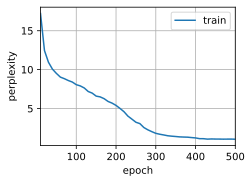

In [48]:
num_epochs, lr = 500, 1
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu())

困惑度 1.5, 50291.2 词元/秒 cuda:0
time travellerit s against reason said filbywhat this fourth dim
travellerit s against reason said filbywhat this fourth dim


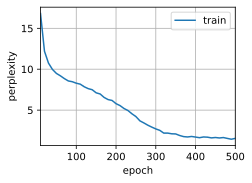

In [49]:
net = RNNModelScratch(len(vocab), num_hiddens, d2l.try_gpu(), get_params,
                    init_rnn_state, rnn)
train_ch8(net, train_iter, vocab, lr, num_epochs, d2l.try_gpu(),
        use_random_iter=True)

### 练习

用ReLU替换本节中使用的激活函数，并重复本节中的实验。我们还需要梯度裁剪吗？为什么？

- 使用ReLU激活函数后，无需进行梯度裁剪。因为原始RNN中采用tanh作为激活函数，而tanh会使得梯度在反向传播时不断缩小或放大，导致出现梯度爆炸或梯度消失的现象。
- 因此需要进行梯度裁剪，避免因过长的求导链出现数值不稳定的现象。而ReLU作为激活函数时，其梯度在输入为正时恒为1，输入为负时恒为0，因此在反向传播时通常不会出现数值不稳定现象，无需进行梯度裁剪。

## 循环神经网络的简洁实现

In [50]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

### 定义模型

In [51]:
num_hiddens = 256
rnn_layer = nn.RNN(len(vocab), num_hiddens)

    我们使用张量来初始化隐状态，形状为(隐藏层数，批量大小，隐藏单元数)

In [52]:
state = torch.zeros((1, batch_size, num_hiddens))
state.shape

torch.Size([1, 32, 256])

通过⼀个隐状态和⼀个输⼊，我们就可以⽤更新后的隐状态计算输出。需要强调的是，rnn_layer的“输出”（Y）不涉及输出层的计算：它是指每个时间步的隐状态，这些隐状态可以⽤作后续输出层的输⼊。

- $Y$：每个时间步的隐状态（还没乘输出层$W_{hq}$），按时间顺序拼在一起。形状(seq_len, batch_size, num_hiddens)
- $state$：整段跑完后的最终隐状态；单层时就是最后一拍的$H$；多层时是每一层各自最后一拍，所以多一个“层数”维。形状(num_layer, batch_size, num_hiddens)

In [53]:
X = torch.rand(size=(num_steps, batch_size, len(vocab)))
Y, state_new = rnn_layer(X, state)
Y.shape, state_new.shape

(torch.Size([35, 32, 256]), torch.Size([1, 32, 256]))

我们为⼀个完整的循环神经⽹络模型定义了⼀个RNNModel类。注意，rnn_layer只包含隐藏的循环层，我们还需要创建⼀个单独的输出层。

In [54]:
#@save
class RNNModel(nn.Module):
    """循环神经网络模型"""
    def __init__(self, rnn_layer, vocab_size, **kwargs):
        super(RNNModel, self).__init__(**kwargs)
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = self.rnn.hidden_size
        # 如果RNN是双向的，num_directions应该是2，否则应该是1
        if not self.rnn.bidirectional:
            self.num_directions = 1
            self.linear = nn.Linear(self.num_hiddens, self.vocab_size)
        else:
            self.num_directions = 2
            self.linear = nn.Linear(self.num_hiddens * 2, self.vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size)
        X = X.to(torch.float32)
        Y, state = self.rnn(X, state)
        # 全连接层首先将Y的形状改为(时间步数*批量大小，隐藏单元数)
        # 它的输出形状是(时间步数*批量大小，词表大小)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # nn.GRU以张量作为隐状态
            return torch.zeros((self.num_directions * self.rnn.num_layers,
                                batch_size, self.num_hiddens), device=device)
        else:
            # nn.LSTM以元组作为隐状态
            return (
                torch.zeros((self.num_directions * self.rnn.num_layers,
                            batch_size, self.num_hiddens), device=device),
                torch.zeros((self.num_directions * self.rnn.num_layers,
                            batch_size, self.num_hiddens), device=device)
                )

### 训练与预测

In [55]:
device = d2l.try_gpu()
net = RNNModel(rnn_layer, vocab_size=len(vocab))
net = net.to(device)
d2l.predict_ch8('time traveller', 10, net, vocab, device)

'time traveller  wwwwwwww'

困惑度 1.3, 390520.5 词元/秒 cuda:0
time traveller held in his hand was a glitteringmetallic framewo
travellerimend thave cumay said the medical man there are b


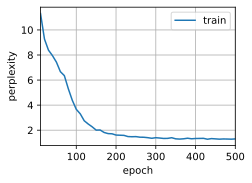

In [56]:
num_epochs, lr = 500, 1
d2l.train_ch8(net, train_iter, vocab, lr, num_epochs, device)

### 练习

尝试使用高级API，能使循环神经网络模型过拟合吗？

---
在高级API中，针对循环神经网络进行了一系列优化，例如nn.RNN源码中增加了可开启的Dropout模块，以及可选的ReLU激活函数，d2l.train_ch8函数中也默认开启了梯度裁剪，这些措施均可以很好的缓解模型在训练时的过拟合问题，使得模型不会轻易发生梯度爆炸。

但是当学习率设置过大时，例如由1增加到10，过大的学习率会使得模型在优化时无法找到最优值，反而螺旋上升，发生梯度爆炸。

如果在循环神经网络模型中增加隐藏层的数量会发生什么？能使模型正常工作吗？

---
增加隐藏层的数量会使得模型变得更加复杂，一定程度上可以提高模型预测效果，但过于复杂的模型也会导致出现过拟合现象。例如将隐藏层由1增加到3，相较于单层隐藏层，模型的困惑度由1.2降低到1，但是token的生成速度也出现了明显下降。

## 通过时间反向传播

### 练习

除了梯度截断，还有其他⽅法来应对循环神经⽹络中的梯度爆炸吗？

- 长短期记忆网络：可以通过引入门控机制或注意力机制的方法，减少梯度异常发生的概率，对循环神经网络进行改进。
- 对权重进行正则化，通过添加L1或L2正则项减少梯度爆炸发生的概率
- 修改激活函数，将激活函数更换为ReLU，可以有效避免梯度爆炸问题